\# Assignment

**Name:** Abhay  
**ID:** 08117702023  
**Class:** BCA V-B  
**Assistant Professor:** Mamta Madan  

---

## Questions based on Decision Tree

**Instructor:** Mamta Madan  
**Points:** 100  
**Due Date:12 september**

---  

# Take any dataset from Kaggle and implement Decision tree( using ID3).

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [ ]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

In [ ]:
# --- ID3 Helpers ---
def entropy(y):
    counts = np.bincount(y)
    probs = counts / len(y)
    return -np.sum([p*np.log2(p) for p in probs if p > 0])

def info_gain(X_col, y, split_val):
    left = y[X_col <= split_val]
    right = y[X_col > split_val]
    if len(left)==0 or len(right)==0:
        return 0
    n = len(y)
    return entropy(y) - (len(left)/n)*entropy(left) - (len(right)/n)*entropy(right)

In [ ]:
# --- ID3 Tree ---
class ID3Tree:
    def __init__(self, depth=None):
        self.depth = depth
        self.tree = None

    def fit(self, X, y, d=0):
        if len(set(y))==1:
            return y[0]
        if self.depth and d>=self.depth:
            return Counter(y).most_common(1)[0][0]

        best_gain, best_feat, best_val = 0, None, None
        for f in range(X.shape[1]):
            for v in np.unique(X[:,f]):
                gain = info_gain(X[:,f], y, v)
                if gain > best_gain:
                    best_gain, best_feat, best_val = gain, f, v
        if best_gain == 0:
            return Counter(y).most_common(1)[0][0]

        left_idx = X[:,best_feat] <= best_val
        right_idx = X[:,best_feat] > best_val
        left = self.fit(X[left_idx], y[left_idx], d+1)
        right = self.fit(X[right_idx], y[right_idx], d+1)
        self.tree = (best_feat, best_val, left, right)
        return self.tree

    def predict_one(self, x, tree=None):
        if tree is None: tree = self.tree
        if not isinstance(tree, tuple):
            return tree
        f,v,l,r = tree
        return self.predict_one(x, l if x[f] <= v else r)

    def predict(self, X):
        return [self.predict_one(x) for x in X]

In [ ]:
# --- Train & Test ---
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
tree = ID3Tree(depth=5)
tree.fit(X_train,y_train)

(2,
 np.float64(1.9),
 np.int64(0),
 (2,
  np.float64(4.7),
  (3, np.float64(1.6), np.int64(1), np.int64(2)),
  (3,
   np.float64(1.7),
   (2,
    np.float64(4.9),
    np.int64(1),
    (3, np.float64(1.5), np.int64(2), np.int64(1))),
   (2,
    np.float64(4.8),
    (0, np.float64(5.9), np.int64(1), np.int64(2)),
    np.int64(2)))))

In [ ]:
y_pred = tree.predict(X_test)

In [ ]:
acc = np.mean(np.array(y_pred)==y_test)
print("Accuracy:", acc)

Accuracy: 1.0


In [ ]:
# --- Pretty Print Function for ID3 Tree ---
def print_tree(tree, feature_names, depth=0):
    if not isinstance(tree, tuple):
        print("  " * depth + f"Leaf -> Class {tree}")
        return
    feature, val, left, right = tree
    print("  " * depth + f"[Feature: {feature_names[feature]} <= {val}]")
    print_tree(left, feature_names, depth+1)
    print("  " * depth + f"[Feature: {feature_names[feature]} > {val}]")
    print_tree(right, feature_names, depth+1)

# Print the trained tree
print_tree(tree.tree, iris.feature_names)

[Feature: petal length (cm) <= 1.9]
  Leaf -> Class 0
[Feature: petal length (cm) > 1.9]
  [Feature: petal length (cm) <= 4.7]
    [Feature: petal width (cm) <= 1.6]
      Leaf -> Class 1
    [Feature: petal width (cm) > 1.6]
      Leaf -> Class 2
  [Feature: petal length (cm) > 4.7]
    [Feature: petal width (cm) <= 1.7]
      [Feature: petal length (cm) <= 4.9]
        Leaf -> Class 1
      [Feature: petal length (cm) > 4.9]
        [Feature: petal width (cm) <= 1.5]
          Leaf -> Class 2
        [Feature: petal width (cm) > 1.5]
          Leaf -> Class 1
    [Feature: petal width (cm) > 1.7]
      [Feature: petal length (cm) <= 4.8]
        [Feature: sepal length (cm) <= 5.9]
          Leaf -> Class 1
        [Feature: sepal length (cm) > 5.9]
          Leaf -> Class 2
      [Feature: petal length (cm) > 4.8]
        Leaf -> Class 2


# now with Sklearn

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

In [ ]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
clf = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
#print("f1_score:", f1_score(y_test, y_pred))
#print("recall:", recall_score(y_test, y_pred))


Accuracy: 1.0


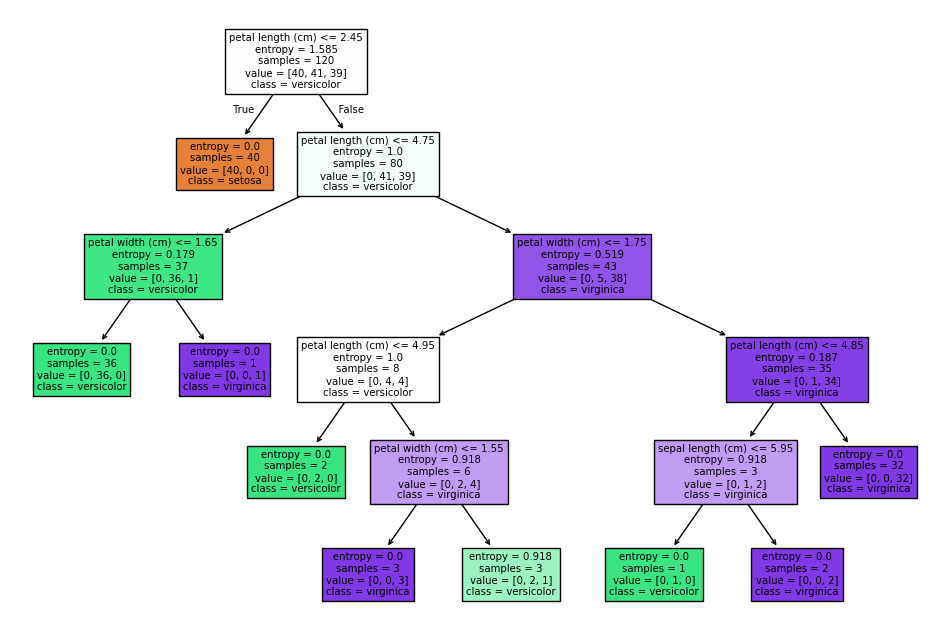

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()